## Mean shift correction to CESM2-WACCM historical TF
This code applies a mean shift bias correction to the historical period of ocean thermal forcing generated with CESM2-WACCM output.  The basis of the correction is the EN4 reanalysis.  We take the 30-year period from 1985-2014 as the climatological baseline for this correction.

CESM2-WACCM is in a rotated polar grid with dimensions `nlat, nlon` rather than `lat, lon`.  Donald has regridded this to rectangular EPSG:3413 grid, and that is what we use here.  Note: depth/`lev` variable is in cm rather than m by default.  The original version of this code corrected that; check the order of magnitude of your depth values before proceeding.


24 Sept 2025 | EHU
- 26 Sept: update to go out to 2300, and write batched files with float32 data type

In [1]:
import os
import sys
import copy
import csv
import time
import datetime
import math
# import dask
import cartopy.crs as ccrs ## map projections
import pandas as pd
import numpy as np
import xarray as xr
import xesmf as xe ## more powerful regridding
import netCDF4 as nc
import matplotlib.pyplot as plt

import rioxarray
from rioxarray.rioxarray import affine_to_coords
from pyproj import CRS

In [4]:
## from cmethods.utils
import warnings
from typing import TYPE_CHECKING, Optional, Union, TypeVar

XRData_t = (xr.Dataset, xr.DataArray)
NPData_t = (list, np.ndarray, np.generic)
XRData = TypeVar("XRData", xr.Dataset, xr.DataArray)
NPData = TypeVar("NPData", list, np.ndarray, np.generic)
MAX_SCALING_FACTOR = 2 ## to allow multiplicative correction?


def check_xr_types(obs: XRData, simh: XRData, simp: XRData) -> None:
    """
    Checks if the parameters are in the correct type. **only used internally**
    """
    phrase: str = "must be type xarray.core.dataarray.Dataset or xarray.core.dataarray.DataArray"

    if not isinstance(obs, XRData_t):
        raise TypeError(f"'obs' {phrase}")
    if not isinstance(simh, XRData_t):
        raise TypeError(f"'simh' {phrase}")
    if not isinstance(simp, XRData_t):
        raise TypeError(f"'simp' {phrase}")

def check_np_types(
    obs: NPData,
    simh: NPData,
    simp: NPData,
) -> None:
    """
    Checks if the parameters are in the correct type. **only used internally**
    """
    phrase: str = "must be type list, np.ndarray or np.generic"

    if not isinstance(obs, NPData_t):
        raise TypeError(f"'obs' {phrase}")
    if not isinstance(simh, NPData_t):
        raise TypeError(f"'simh' {phrase}")
    if not isinstance(simp, NPData_t):
        raise TypeError(f"'simp' {phrase}")

def nan_or_equal(value1: float, value2: float) -> bool:
    """
    Returns True if the values are equal or at least one is NaN

    :param value1: First value to check
    :type value1: float
    :param value2: Second value to check
    :type value2: float
    :return: If any value is NaN or values are equal
    :rtype: bool
    """
    return np.isnan(value1) or np.isnan(value2) or value1 == value2
        
def ensure_dividable(
    numerator: Union[float, np.ndarray],
    denominator: Union[float, np.ndarray],
    max_scaling_factor: float,
) -> np.ndarray:
    """
    Ensures that the arrays can be divided. The numerator will be multiplied by
    the maximum scaling factor of the CMethods class if division by zero.

    :param numerator: Numerator to use
    :type numerator: np.ndarray
    :param denominator: Denominator that can be zero
    :type denominator: np.ndarray
    :return: Zero-ensured division
    :rtype: np.ndarray | float
    """
    with np.errstate(divide="ignore", invalid="ignore"):
        result = numerator / denominator

    if isinstance(numerator, np.ndarray):
        mask_inf = np.isinf(result)
        result[mask_inf] = numerator[mask_inf] * max_scaling_factor  # type: ignore[index]

        mask_nan = np.isnan(result)
        result[mask_nan] = 0  # type: ignore[index]
    elif np.isinf(result):
        result = numerator * max_scaling_factor
    elif np.isnan(result):
        result = 0.0

    return result

def get_pdf(
    x: Union[list, np.ndarray],
    xbins: Union[list, np.ndarray],
) -> np.ndarray:
    r"""
    Compuites and returns the the probability density function :math:`P(x)`
    of ``x`` based on ``xbins``.

    :param x: The vector to get :math:`P(x)` from
    :type x: list | np.ndarray
    :param xbins: The boundaries/bins of :math:`P(x)`
    :type xbins: list | np.ndarray
    :return: The probability densitiy function of ``x``
    :rtype: np.ndarray

    .. code-block:: python
        :linenos:
        :caption: Compute the probability density function :math:`P(x)`

        >>> from cmethods get_pdf

        >>> x = [1, 2, 3, 4, 5, 5, 5, 6, 7, 8, 9, 10]
        >>> xbins = [0, 3, 6, 10]
        >>> print(get_pdf(x=x, xbins=xbins))
        [2, 5, 5]
    """
    pdf, _ = np.histogram(x, xbins)
    return pdf


def get_cdf(
    x: Union[list, np.ndarray],
    xbins: Union[list, np.ndarray],
) -> np.ndarray:
    r"""
    Computes and returns returns the cumulative distribution function :math:`F(x)`
    of ``x`` based on ``xbins``.

    :param x: Vector to get :math:`F(x)` from
    :type x: list | np.ndarray
    :param xbins: The boundaries/bins of :math:`F(x)`
    :type xbins: list | np.ndarray
    :return: The cumulative distribution function of ``x``
    :rtype: np.ndarray


    .. code-block:: python
        :linenos:
        :caption: Compute the cumulative distribution function :math:`F(x)`

        >>> from cmethods.utils import get_cdf

        >>> x = [1, 2, 3, 4, 5, 5, 5, 6, 7, 8, 9, 10]
        >>> xbins = [0, 3, 6, 10]
        >>> print(get_cdf(x=x, xbins=xbins))
        [0.0, 0.16666667, 0.58333333, 1.]
    """
    pdf, _ = np.histogram(x, xbins)
    cdf = np.insert(np.cumsum(pdf), 0, 0.0)
    return cdf / cdf[-1]


def get_inverse_of_cdf(
    base_cdf: Union[list, np.ndarray],
    insert_cdf: Union[list, np.ndarray],
    xbins: Union[list, np.ndarray],
) -> np.ndarray:
    r"""
    Returns the inverse cumulative distribution function as:
    :math:`F^{-1}_{x}\left[y\right]` where :math:`x` represents ``base_cdf`` and
    ``insert_cdf`` is represented by :math:`y`.

    :param base_cdf: The basis
    :type base_cdf: list | np.ndarray
    :param insert_cdf: The CDF that gets inserted
    :type insert_cdf: list | np.ndarray
    :param xbins: Probability boundaries
    :type xbins: list | np.ndarray
    :return: The inverse CDF
    :rtype: np.ndarray
    """
    return np.interp(insert_cdf, base_cdf, xbins)


In [5]:
def quantile_delta_mapping(
    obs: NPData,
    simh: NPData,
    simp: NPData,
    n_quantiles: int,
    kind: str = "+",
    **kwargs,
    ) -> NPData:
    r"""
    Based on https://python-cmethods.readthedocs.io/en/latest/methods.html#quantile-delta-mapping

    kind: str, default + for additive, can be set to * for multiplicative
    """
    # check_adjust_called(
    #     function_name="quantile_delta_mapping",
    #     adjust_called=kwargs.get("adjust_called"),
    # )
    check_np_types(obs=obs, simh=simh, simp=simp)

    if not isinstance(n_quantiles, int):
        raise TypeError("'n_quantiles' must be type int")

    if kind=='+':
        obs, simh, simp = (
            np.array(obs),
            np.array(simh),
            np.array(simp),
        )  # to achieve higher accuracy
        global_max = kwargs.get("global_max", max(np.nanmax(obs), np.nanmax(simh)))
        global_min = kwargs.get("global_min", min(np.nanmin(obs), np.nanmin(simh)))

        if nan_or_equal(value1=global_max, value2=global_min):
            return simp

        wide = abs(global_max - global_min) / n_quantiles
        xbins = np.arange(global_min, global_max + wide, wide)

        cdf_obs = get_cdf(obs, xbins)
        cdf_simh = get_cdf(simh, xbins)
        cdf_simp = get_cdf(simp, xbins)

        # calculate exact CDF values of $F_{sim,p}[T_{sim,p}(t)]$
        epsilon = np.interp(simp, xbins, cdf_simp)  # Eq. 1.1
        QDM1 = get_inverse_of_cdf(cdf_obs, epsilon, xbins)  # Eq. 1.2
        delta = simp - get_inverse_of_cdf(cdf_simh, epsilon, xbins)  # Eq. 1.3
        return QDM1 + delta  # Eq. 1.4

    if kind=='*':
        obs, simh, simp = np.array(obs), np.array(simh), np.array(simp)
        global_max = kwargs.get("global_max", max(np.nanmax(obs), np.nanmax(simh)))
        global_min = kwargs.get("global_min", 0.0)
        if nan_or_equal(value1=global_max, value2=global_min):
            return simp

        wide = global_max / n_quantiles
        xbins = np.arange(global_min, global_max + wide, wide)

        cdf_obs = get_cdf(obs, xbins)
        cdf_simh = get_cdf(simh, xbins)
        cdf_simp = get_cdf(simp, xbins)

        epsilon = np.interp(simp, xbins, cdf_simp)  # Eq. 1.1
        QDM1 = get_inverse_of_cdf(cdf_obs, epsilon, xbins)  # Eq. 1.2

        delta = ensure_dividable(  # Eq. 2.3
            simp,
            get_inverse_of_cdf(cdf_simh, epsilon, xbins),
            max_scaling_factor=kwargs.get(
                "max_scaling_scaling",
                MAX_SCALING_FACTOR,
            ),
        )
        return QDM1 * delta  # Eq. 2.4
    raise NotImplementedError(
        f"{kind=} not available for quantile_delta_mapping. Use '+' or '*' instead.",
    )


def apply_cmfunc(
    method: str,
    obs: XRData,
    simh: XRData,
    simp: XRData,
    **kwargs: dict,
) -> XRData:
    """
    Internal function used to apply the bias correction technique to the
    passed input data.
    """
    ## hard-code the QDM method
    if method!='quantile_delta_mapping':
        raise UnknownMethodError('Not implemented for methods other than quantile_delta_mapping')
        ## give this a default for what we want to do
    else:
        method='quantile_delta_mapping' ## not actually going to use this
    
    check_xr_types(obs=obs, simh=simh, simp=simp)
    # if method not in __METHODS_FUNC__:
    #     raise UnknownMethodError(method, __METHODS_FUNC__.keys())

    if kwargs.get("input_core_dims"):
        if not isinstance(kwargs["input_core_dims"], dict):
            raise TypeError("input_core_dims must be an object of type 'dict'")
        if not len(kwargs["input_core_dims"]) == 3 or any(
            not isinstance(value, str) for value in kwargs["input_core_dims"].values()
        ):
            raise ValueError(
                'input_core_dims must have three key-value pairs like: {"obs": "time", "simh": "time", "simp": "time"}',
            )

        input_core_dims = kwargs.pop("input_core_dims")
    else:
        input_core_dims = {"obs": "time", "simh": "time", "simp": "time"}

    result: XRData = xr.apply_ufunc(
        quantile_delta_mapping,
        obs,
        simh,
        # Need to spoof a fake time axis since 'time' coord on full dataset is
        # different than 'time' coord on training dataset.
        simp.rename({input_core_dims["simp"]: "__t_simp__"}),
        dask="parallelized",
        vectorize=True,
        # This will vectorize over the time dimension, so will submit each grid
        # cell independently
        input_core_dims=[
            [input_core_dims["obs"]],
            [input_core_dims["simh"]],
            ["__t_simp__"],
        ],
        # Need to denote that the final output dataset will be labeled with the
        # spoofed time coordinate
        output_core_dims=[["__t_simp__"]],
        kwargs=dict(kwargs),
    )

    # Rename to proper coordinate name.
    result = result.rename({"__t_simp__": input_core_dims["simp"]})

    # ufunc will put the core dimension to the end (time), so want to preserve
    # original order where time is commonly first.
    return result.transpose(*obs.rename({input_core_dims["obs"]: input_core_dims["simp"]}).dims)


In [6]:
## Time utils from Bryan Riel
## pasting stuff from iceutils below.
#-*- coding: utf-8 -*-

def tdec2datestr(tdec_in, returndate=False):
    """
    Convert a decimaly year to an iso date string.
    """
    if isinstance(tdec_in, (list, np.ndarray)):
        tdec_list = copy.deepcopy(tdec_in)
    else:
        tdec_list = [tdec_in]
    current_list = []
    for tdec in tdec_list:
        year = int(tdec)
        yearStart = datetime.datetime(year, 1, 1)
        if year % 4 == 0:
            ndays_in_year = 366.0
        else:
            ndays_in_year = 365.0
        days = (tdec - year) * ndays_in_year
        seconds = (days - int(days)) * 86400
        tdelta = datetime.timedelta(days=int(days), seconds=int(seconds))
        current = yearStart + tdelta
        if not returndate:
            current = current.isoformat(' ').split()[0]
        current_list.append(current)

    if len(current_list) == 1:
        return current_list[0]
    else:
        return np.array(current_list)


def datestr2tdec(yy=0, mm=0, dd=0, hour=0, minute=0, sec=0, microsec=0, dateobj=None):
    """
    Convert year, month, day, hours, minutes, seconds to decimal year.
    """
    if dateobj is not None:
        if type(dateobj) == str:
            yy, mm, dd = [int(val) for val in dateobj.split('-')]
            hour, minute, sec = [0, 0, 0]
        elif type(dateobj) == datetime.datetime:
            attrs = ['year', 'month', 'day', 'hour', 'minute', 'second']
            yy, mm, dd, hour, minute, sec = [getattr(dateobj, attr) for attr in attrs]
        elif type(dateobj) == np.datetime64:
            yy = dateobj.astype('datetime64[Y]').astype(int) + 1970
            mm = dateobj.astype('datetime64[M]').astype(int) % 12 + 1
            days = (
                (dateobj - dateobj.astype('datetime64[M]')) / np.timedelta64(1, 'D')
            )
            dd = int(days) + 1
            hour, minute, sec = [0, 0, 0]
        else:
            raise NotImplementedError('dateobj must be str, datetime, or np.datetime64.')

    # Make datetime object for start of year
    yearStart = datetime.datetime(yy, 1, 1, 0, 0, 0)
    # Make datetime object for input time
    current = datetime.datetime(yy, mm, dd, hour, minute, sec, microsec)
    # Compute number of days elapsed since start of year
    tdelta = current - yearStart
    # Convert to decimal year and account for leap year
    if yy % 4 == 0:
        return float(yy) + tdelta.total_seconds() / (366.0 * 86400)
    else:
        return float(yy) + tdelta.total_seconds() / (365.0 * 86400)

### Load in data

In [3]:
SelModel = 'CESM2-WACCM'
BaselinePeriod = ['1985','2014'] ## climatological baseline for QDM
YearsIncluded = ['1850', '2300'] ## set these to the endpoints if you want to slice the CESM2 data.
PressureIncluded = True ## whether to use files that already account for pressure effect on freezing point
## EN4 data run 1950-2014, but we will use it only during the BaselinePeriod anyway

DirSave = f'/Users/dfelikso/Research/Projects/ISMIP7/gris-iceocean-process/gris-iceocean-outfiles/'
DirIn = f'/Users/eultee/Desktop/'
if PressureIncluded:
    DirIn = DirIn + f'/TF-PressureIncluded/'
else:
    # DirIn = DirIn + f'/FP_in_Step3/'
    print('Confirm pressure handling in your dataset and set the read-in directory accordingly.')

DirHadley = f'/Users/dfelikso/Research/Projects/ISMIP7/gris-iceocean-process/gris-iceocean-outfiles'
HadleyFile = f'/tf-Hadley-1950_2020_regrid.nc'

In [4]:
## Load EN4 using xarray
ds1 = xr.open_dataset(DirHadley+HadleyFile, decode_times='timeDim')
ds1

<xarray.Dataset> Size: 6MB
Dimensions:  (time: 12, depth: 41, y: 73, x: 43)
Coordinates:
  * time     (time) datetime64[ns] 96B 2007-01-16T12:00:00 ... 2007-12-16T12:...
  * depth    (depth) float32 164B 0.0 50.0 100.0 ... 1.9e+03 1.95e+03 2e+03
  * y        (y) float32 292B -3.45e+06 -3.41e+06 ... -6.1e+05 -5.7e+05
  * x        (x) float32 172B -7.2e+05 -6.8e+05 -6.4e+05 ... 9.2e+05 9.6e+05
    lat      (y, x) float32 13kB ...
    lon      (y, x) float32 13kB ...
Data variables:
    TF       (time, depth, y, x) float32 6MB ...

In [5]:
## load in CESM TF for all time slices available, using multifile dataset
ds3 = xr.open_mfdataset(f'{DirIn}/TF_Omon_CESM2*.nc').sel(time=slice(YearsIncluded[0], YearsIncluded[1]))
ds3

OSError: no files to open

In [8]:
# with dask.config.set(**{'array.slicing.split_large_chunks': True}): ## mitigate performance problem with slicing
ds_m = ds3.where(ds3.TF<1e20)
ds_m.mean().compute()

<xarray.Dataset> Size: 4B
Dimensions:  ()
Data variables:
    TF       float32 4B 10.59

Depth resampling seemed to be smearing fill value across depth levels, so that the mean of depth-resampled dataset was ~5e17, even when fill values masked out.  Created `ds_m`  before resampling to address this issue.

### Apply DateTimeIndex

In [10]:
# test_ds_full = tfCESM_renamed.TF.sel(time=slice(YearsIncluded[0], YearsIncluded[1]))
test_ds_full = ds_m.TF.sel(time=slice(YearsIncluded[0], YearsIncluded[1]))

# ## aligning the time indices
# test_ds_full = test_ds_full.assign_coords(new_time = ('time', test_ds_full.indexes['time'].to_datetimeindex().values))
# test_ds_full = test_ds_full.drop_indexes('time')
# test_ds_full = test_ds_full.set_xindex('new_time').drop_vars('time')

## aligning the names of the variables between obs and sim
test_ds_full = test_ds_full.to_dataset()
# test_ds_full = test_ds_full.rename({'new_time': 'time'})
test_ds_full

<xarray.Dataset> Size: 3GB
Dimensions:  (time: 5400, depth: 41, y: 73, x: 43)
Coordinates:
  * time     (time) object 43kB 1850-01-15 13:00:00.000008 ... 2299-12-15 12:...
  * depth    (depth) float32 164B 0.0 50.0 100.0 ... 1.9e+03 1.95e+03 2e+03
  * y        (y) float32 292B -3.45e+06 -3.41e+06 ... -6.1e+05 -5.7e+05
  * x        (x) float32 172B -7.2e+05 -6.8e+05 -6.4e+05 ... 9.2e+05 9.6e+05
    lat      (y, x) float32 13kB dask.array<chunksize=(73, 43), meta=np.ndarray>
    lon      (y, x) float32 13kB dask.array<chunksize=(73, 43), meta=np.ndarray>
Data variables:
    TF       (time, depth, y, x) float32 3GB dask.array<chunksize=(660, 14, 25, 11), meta=np.ndarray>

In [11]:
# tobs_ds_full = ds1.TF.interp(depth=test_ds_full.depth.values) ## Donald also handled depth sampling
tobs_ds_full = ds1.TF
tobs_ds_full = tobs_ds_full.convert_calendar('noleap')

---
### Check output here and in next step - 27 Aug

Text(0.5, 0.98, 'June 1984 - 0m depth')

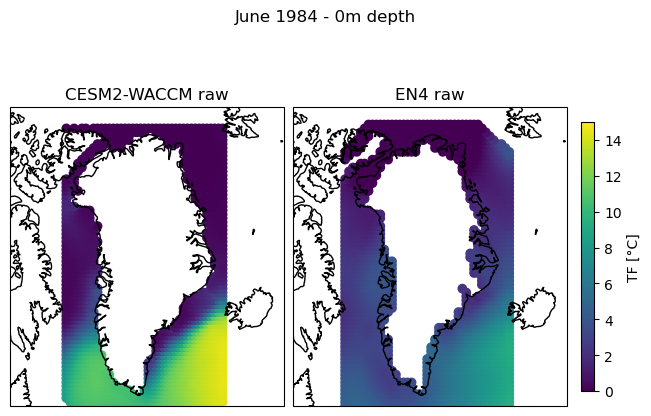

In [12]:
depth_toplot=0
TF_toplot_sim = test_ds_full.TF.sel(time='1984-06-30', depth=depth_toplot, method='nearest')
TF_toplot_obs = tobs_ds_full.sel(time='1984-06-30', depth=depth_toplot, method='nearest')

# obs_x, obs_y = np.meshgrid(tobs_ds_full.lon, tobs_ds_full.lat)

### Limits of Greenland domain ###
limN           = 86.0 ## degrees N latitude
limS           = 57.0 ## degrees N latitude
limE           = 4.0 ## degrees E latitude
limW           = 274.0 ## degrees E latitude

GrIS_polar_stereo = ccrs.Stereographic(
            central_latitude=90.0,
            central_longitude=-45.0,
            false_easting=0.0,
            false_northing=0.0,
            true_scale_latitude=70.0,
            globe=ccrs.Globe('WGS84')
        )

fig, axs = plt.subplots(1,2, layout='constrained',
                        subplot_kw={'projection': GrIS_polar_stereo, 'extent':  [-65, -20, limS, limN]})

sc_sim = axs[0].scatter(y=test_ds_full.lat, x=test_ds_full.lon, 
                        c=TF_toplot_sim, transform=ccrs.PlateCarree(),
                        cmap='viridis', vmin=0., vmax=15.);
axs[0].set(aspect=1, title='CESM2-WACCM raw')
axs[0].coastlines()
# cbar1 = plt.colorbar(sc_sim, orientation='vertical', label='TF [°C]')

sc_obs = axs[1].scatter(y=TF_toplot_obs.lat, x=TF_toplot_obs.lon, 
                        c=TF_toplot_obs, transform=ccrs.PlateCarree(),
                        cmap='viridis', vmin=0., vmax=15.);
axs[1].set(aspect=1, title='EN4 raw')
axs[1].coastlines()
cbar2 = plt.colorbar(sc_obs, orientation='vertical', label='TF [°C]', shrink=0.6)

fig.suptitle('June 1984 - {}m depth'.format(depth_toplot))

## Apply mean correction
Compute mean of EN4 and CESM2-WACCM over baseline period, for every pixel and depth level.  Remove the CESM2-WACCM pixel-wise mean for all time steps, and add the EN4 pixel-wise mean.

In [14]:
## 
## cftime slicing
import cftime as cftime

CESM_meanval = test_ds_full.sel(time=slice(cftime.DatetimeNoLeap(int(BaselinePeriod[0]),1,1), 
                                           cftime.DatetimeNoLeap(int(BaselinePeriod[1]),12,31))).mean(dim='time')
reanalysis_meanval = tobs_ds_full.sel(time=slice(cftime.DatetimeNoLeap(int(BaselinePeriod[0]),1,1), 
                                           cftime.DatetimeNoLeap(int(BaselinePeriod[1]),12,31))).mean(dim='time')

CESM_demean = test_ds_full - CESM_meanval
CESM_corrected = CESM_demean + reanalysis_meanval
CESM_corrected

<xarray.Dataset> Size: 3GB
Dimensions:  (time: 5400, depth: 41, y: 73, x: 43)
Coordinates:
  * time     (time) object 43kB 1850-01-15 13:00:00.000008 ... 2299-12-15 12:...
  * depth    (depth) float32 164B 0.0 50.0 100.0 ... 1.9e+03 1.95e+03 2e+03
  * y        (y) float32 292B -3.45e+06 -3.41e+06 ... -6.1e+05 -5.7e+05
  * x        (x) float32 172B -7.2e+05 -6.8e+05 -6.4e+05 ... 9.2e+05 9.6e+05
    lat      (y, x) float32 13kB 58.27 58.34 58.4 58.46 ... 80.34 80.03 79.72
    lon      (y, x) float32 13kB -56.79 -56.15 -55.51 ... 12.07 13.22 14.3
Data variables:
    TF       (time, depth, y, x) float32 3GB dask.array<chunksize=(660, 14, 25, 11), meta=np.ndarray>

### Check output

Text(0.5, 0.98, '2150-01-31 00:00:00 - 0m depth')

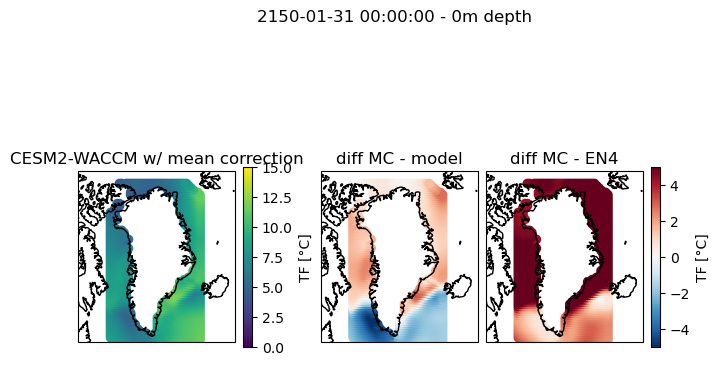

In [17]:
## what does it look like?

depth_toplot=0
# date_toplot = '2050-01-30'
date_toplot = cftime.DatetimeNoLeap(2150,1,31) ## cftime
TF_toplot_sim = test_ds_full.TF.sel(time=date_toplot, depth=depth_toplot, method='nearest')
TF_toplot_obs = tobs_ds_full.sel(time=date_toplot, depth=depth_toplot, method='nearest')
TF_toplot_mc = CESM_corrected.TF.sel(time=date_toplot, depth=depth_toplot, method='nearest')

# obs_x, obs_y = np.meshgrid(tobs_ds_full.lon, tobs_ds_full.lat)

### Limits of Greenland domain ###
limN           = 86.0 ## degrees N latitude
limS           = 57.0 ## degrees N latitude
limE           = 4.0 ## degrees E latitude
limW           = 274.0 ## degrees E latitude

GrIS_polar_stereo = ccrs.Stereographic(
            central_latitude=90.0,
            central_longitude=-45.0,
            false_easting=0.0,
            false_northing=0.0,
            true_scale_latitude=70.0,
            globe=ccrs.Globe('WGS84')
        )

fig, axs = plt.subplots(1,3, layout='constrained',
                        subplot_kw={'projection': GrIS_polar_stereo, 'extent':  [-65, -20, limS, limN]})

sc_qdm = axs[0].scatter(y=TF_toplot_mc.lat, x=TF_toplot_mc.lon, 
                        c=TF_toplot_mc, transform=ccrs.PlateCarree(),
                        cmap='viridis', vmin=0., vmax=15.);
axs[0].set(aspect=1, title='CESM2-WACCM w/ mean correction')
axs[0].coastlines()
cbar1 = plt.colorbar(sc_qdm, orientation='vertical', label='TF [°C]', shrink=0.4)

sc_simdiff = axs[1].scatter(y=TF_toplot_sim.lat, x=TF_toplot_sim.lon, 
                        c=TF_toplot_mc-TF_toplot_sim, transform=ccrs.PlateCarree(),
                        cmap='RdBu_r', vmin=-5., vmax=5.);
axs[1].set(aspect=1, title='diff MC - model')
axs[1].coastlines()
# cbar2 = plt.colorbar(sc_obs, orientation='vertical', label='TF [°C]', shrink=0.4)

sc_obsdiff = axs[2].scatter(y=TF_toplot_mc.lat, x=TF_toplot_mc.lon, 
                        c=TF_toplot_mc-TF_toplot_obs, transform=ccrs.PlateCarree(),
                        cmap='RdBu_r', vmin=-5., vmax=5.);
axs[2].set(aspect=1, title='diff MC - EN4')
axs[2].coastlines()
cbar2 = plt.colorbar(sc_obsdiff, orientation='vertical', label='TF [°C]', shrink=0.4)

fig.suptitle('{} - {}m depth'.format(date_toplot, depth_toplot))

In [18]:
## test write out
from datetime import datetime, date

now = datetime.now()
ds_temp = CESM_corrected 
ds_out = ds_temp.assign_attrs(title='Mean-corrected ocean thermal forcing for {}'.format(SelModel),
                             summary='TF computed following Verjans code, in a bounding' + 
                              ' box around Greenland, for ISMIP7 Greenland forcing. ' +
                              ' Mean correction applied based on Hadley data 1985-2014.',
                             institution='NASA Goddard Space Flight Center',
                             creation_date=now.strftime('%Y-%m-%d %H:%M:%S'))

ds_reduced = ds_out.astype('float32')
ds_reduced

<xarray.Dataset> Size: 3GB
Dimensions:  (time: 5400, depth: 41, y: 73, x: 43)
Coordinates:
  * time     (time) object 43kB 1850-01-15 13:00:00.000008 ... 2299-12-15 12:...
  * depth    (depth) float32 164B 0.0 50.0 100.0 ... 1.9e+03 1.95e+03 2e+03
  * y        (y) float32 292B -3.45e+06 -3.41e+06 ... -6.1e+05 -5.7e+05
  * x        (x) float32 172B -7.2e+05 -6.8e+05 -6.4e+05 ... 9.2e+05 9.6e+05
    lat      (y, x) float32 13kB 58.27 58.34 58.4 58.46 ... 80.34 80.03 79.72
    lon      (y, x) float32 13kB -56.79 -56.15 -55.51 ... 12.07 13.22 14.3
Data variables:
    TF       (time, depth, y, x) float32 3GB dask.array<chunksize=(660, 14, 25, 11), meta=np.ndarray>
Attributes:
    title:          Mean-corrected ocean thermal forcing for CESM2-WACCM
    summary:        TF computed following Verjans code, in a bounding box aro...
    institution:    NASA Goddard Space Flight Center
    creation_date:  2025-09-26 13:33:59

In [19]:
if PressureIncluded:
    p_tag = 'IncludingPressure'
else:
    p_tag = 'NoPressure'

YearTags = [(1850,2014), 
            (2015,2100),
            (2101,2300)]

ds_splits = [ds_reduced.sel(time=slice(cftime.DatetimeNoLeap(yt[0], 1, 1), cftime.DatetimeNoLeap(yt[1], 12, 31))) for yt in YearTags]
ds_splits[1]

<xarray.Dataset> Size: 531MB
Dimensions:  (time: 1032, depth: 41, y: 73, x: 43)
Coordinates:
  * time     (time) object 8kB 2015-01-15 13:00:00.000008 ... 2100-12-15 12:0...
  * depth    (depth) float32 164B 0.0 50.0 100.0 ... 1.9e+03 1.95e+03 2e+03
  * y        (y) float32 292B -3.45e+06 -3.41e+06 ... -6.1e+05 -5.7e+05
  * x        (x) float32 172B -7.2e+05 -6.8e+05 -6.4e+05 ... 9.2e+05 9.6e+05
    lat      (y, x) float32 13kB 58.27 58.34 58.4 58.46 ... 80.34 80.03 79.72
    lon      (y, x) float32 13kB -56.79 -56.15 -55.51 ... 12.07 13.22 14.3
Data variables:
    TF       (time, depth, y, x) float32 531MB dask.array<chunksize=(344, 14, 25, 11), meta=np.ndarray>
Attributes:
    title:          Mean-corrected ocean thermal forcing for CESM2-WACCM
    summary:        TF computed following Verjans code, in a bounding box aro...
    institution:    NASA Goddard Space Flight Center
    creation_date:  2025-09-26 13:33:59

In [23]:
from dask.diagnostics import ProgressBar

for yt, ds in zip(YearTags, ds_splits):
    print('Processing years {}-{}'.format(yt[0],yt[1]))

    out_fn = DirSave + '/tf_MeanCorrected-AllLevels-CommonGrid-{}-{}_{}-{}-{}.nc'.format(SelModel, 
                                                            yt[0], yt[1],
                                                            p_tag,
                                                            now.strftime('%Y%m%d'))

    with ProgressBar():
        ds.to_netcdf(path=out_fn)

Processing years 1850-2014
[########################################] | 100% Completed | 5.24 sms
Processing years 2015-2100
[########################################] | 100% Completed | 3.36 sms
Processing years 2101-2300
[########################################] | 100% Completed | 6.77 sms
